# Industrial quality assurance for metal castings

Classical image processing and classical machine learning, no neural networks.

- **Author:** Hussein Loubani
- **Dataset:** Kaggle *casting product image data for quality inspection*, `casting_512x512` only: 1,300 unaugmented top-down photographs of submersible pump impellers
- **Task:** classify each casting as defective or sound, time the algorithm, and box the defect when one is detected
- **Primary metric:** F1 for the defective class, chosen before modeling; recall on that class is the guardrail

### Table of contents

1. [Imports and setup](#1.-Imports-and-setup)
2. [The data](#2.-The-data)
3. [Audit and cleaning](#3.-Audit-and-cleaning)
4. [The same casting, photographed twice](#4.-The-same-casting,-photographed-twice)
5. [Three partitions](#5.-Three-partitions)
6. [Exploring the images](#6.-Exploring-the-images)
7. [Locating the part](#7.-Locating-the-part)
8. [The inspection pipeline](#8.-The-inspection-pipeline)
9. [What separates the classes](#9.-What-separates-the-classes)
10. [Design decisions, each tested](#10.-Design-decisions,-each-tested)
11. [Learned classifiers](#11.-Learned-classifiers)
12. [Robustness to the photograph](#12.-Robustness-to-the-photograph)
13. [Final evaluation on the sealed test split](#13.-Final-evaluation-on-the-sealed-test-split)
14. [Finding the defect, not just naming it](#14.-Finding-the-defect,-not-just-naming-it)
15. [Processing time](#15.-Processing-time)
16. [Conclusion, limitations, and recommendations](#16.-Conclusion,-limitations,-and-recommendations)

## 1. Imports and setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from casting_qa import config
from casting_qa.dataset import (
    audit_inventory,
    audit_summary,
    build_inventory,
    class_balance,
    clean_inventory,
    load_grayscale,
    partition_of,
    split_inventory,
    split_summary,
    stratified_sample,
    write_processed,
)
from casting_qa.duplicates import (
    cross_partition_pairs,
    duplicate_groups,
    images_with_a_twin_in,
    pairwise_similarity,
    signatures,
    similar_pairs,
    threshold_sweep,
)
from casting_qa.features import (
    decomposition_check,
    describe_batch,
    feature_columns,
    pipeline_stages,
    quality_batch,
    quality_metrics,
)
from casting_qa.geometry import class_profiles, otsu_largest_share, unwrap
from casting_qa.localize import (
    box_rates,
    fit_localizer,
    inspect_casting,
    inspection_gallery,
    quantile_curve,
    ring_histograms,
)
from casting_qa.modeling.classify import (
    apply_or_gate,
    apply_rule,
    build_models,
    compare_models,
    decision_scores,
    evaluate,
    exposure_matched_pairs,
    fit_or_gate,
    fit_rule,
    grouped_cv_rates,
    headline_intervals,
    matched_control,
    mcnemar_exact,
    operating_points,
    repeated_cv,
    report,
    separation_table,
    time_inspection,
    tune,
)
from casting_qa.plots import (
    apply_style,
    plot_class_balance,
    plot_confound,
    plot_confusion,
    plot_detection_grid,
    plot_duplicate_pairs,
    plot_errors,
    plot_feature_separation,
    plot_localizer_reference,
    plot_model_comparison,
    plot_pipeline_stages,
    plot_quality_by_class,
    plot_radial_profile,
    plot_robustness,
    plot_sample_grid,
    plot_similarity_distribution,
    save_figure,
)
from casting_qa.robustness import augment_batch, perturbed_features, robustness_table

apply_style()
pd.set_option("display.width", 140)

All logic lives in the `casting_qa` package under `src/`, installed in editable mode, and every constant is in `config.py`. The notebook calls functions and interprets what they return. Parallel steps use all cores but one.

## 2. The data

,label,images,share_%
0,ok,519,39.9
1,defective,781,60.1


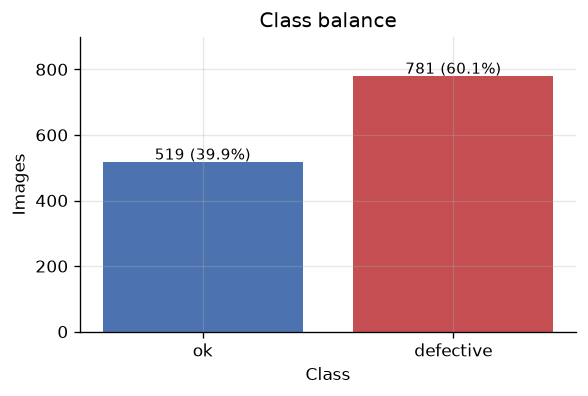

In [2]:
inventory = build_inventory()
balance = class_balance(inventory)
display(balance)
fig = plot_class_balance(balance)
plt.show()
save_figure(fig, "class_balance", "eda")

**The classes are 60/40, not 50/50:** 781 defective and 519 sound. Predicting "defective" for everything would score 60% accuracy while telling a factory nothing, so accuracy alone is a poor summary. The primary metric is F1 on the defective class, which charges for missed defects and false alarms at once, and every partition below is stratified so it keeps this balance.

## 3. Audit and cleaning

One pass over all 1,300 files records size, color mode, whether the three stored color planes are identical, an intensity summary, and a hash of the decoded pixels. The hash is of pixels rather than file bytes, because two JPEGs can differ byte for byte and decode to the same picture. This pass reads pixels only to check that each file is usable; no label-dependent analysis happens before the split.

In [3]:
audited = audit_inventory(inventory)
display(audit_summary(audited))

cleaned, removed = clean_inventory(audited)
print(f"cleaned: {len(inventory):,} -> {len(cleaned):,} images, {len(removed)} removed")
print(f"stored modes: {audited['mode'].value_counts().to_dict()}")

,check,count
0,images,1300
1,unreadable,0
2,not 512x512,0
3,color planes differ,0
4,identical decoded pixels,0
5,blank (zero variance),0


cleaned: 1,300 -> 1,300 images, 0 removed
stored modes: {'RGB': 1300}


**The audit comes back clean, and the checks are still worth their place:** every file opens, every image is 512x512, all 1,300 are stored as three-channel RGB JPEG with bit-identical planes, no two decode to the same pixels, and none is blank. The dataset description calls the images grayscale; the files are RGB carrying one channel of information three times. Decoding straight to one channel takes each image from 786 KB to 262 KB in memory without losing anything, which is what the loader does. The cleaning rules fire zero times here and would fire loudly on a corrupted download.

## 4. The same casting, photographed twice

A clean hash audit only rules out identical files. It says nothing about the same physical casting photographed twice at different rotations, which is a different picture with the same metal in it. If one of those photographs lands in the training data and the other in the test data, the test score partly measures recognition of a part the model has already seen.

**The signature:** the rim band is unwrapped to polar coordinates in units of the cavity radius, so scale drops out and a rotation becomes a cyclic shift along the angle axis. Everything every casting shares is then removed: slow shading by a spatial high-pass, the circular machining grooves by subtracting the mean over angle at each radius, and the rig's fixed lighting gradient by a second high-pass along the angle. What remains is scratches, chips and casting marks, the detail unique to one piece of metal.

**The comparison:** two signatures are compared by normalized cross-correlation at the best cyclic shift. Correlation at every shift is the inverse FFT of one spectrum times the conjugate of the other, so all 720 rotations, in half-degree steps, are tried at once, and all 844,350 pairs take seconds.

844,350 pairs; quantiles 50/99/99.9%: [0.059 0.268 0.538]


,threshold,pairs,cross_label_pairs,est_false_match_%,images_with_a_twin,largest_group
0,0.8,240,0,0.0,383,6
1,0.7,413,0,0.0,557,7
2,0.6,637,1,0.3,721,32
3,0.5,1071,52,10.1,893,96
4,0.4,2326,318,28.5,1036,343


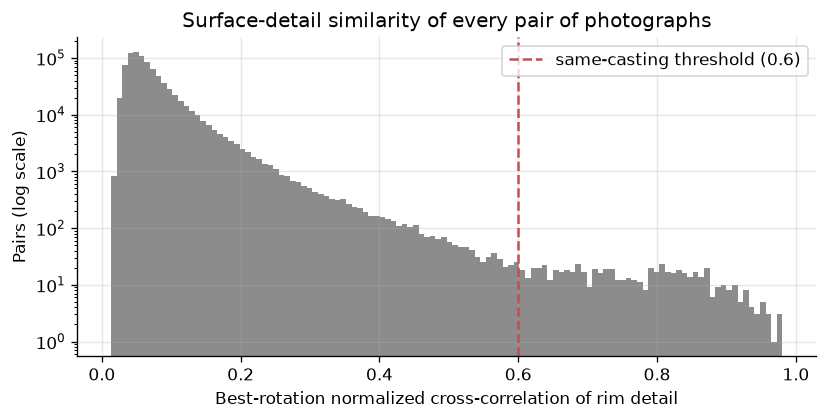

In [4]:
stack = signatures(cleaned["path"], load_grayscale)
similarity = pairwise_similarity(stack)
scores = similarity[np.triu_indices(len(cleaned), k=1)]
print(f"{len(scores):,} pairs; quantiles 50/99/99.9%: {np.round(np.quantile(scores, [0.5, 0.99, 0.999]), 3)}")

display(threshold_sweep(similarity, cleaned["label"], thresholds=(0.8, 0.7, 0.6, 0.5, 0.4)))
fig = plot_similarity_distribution(scores, config.DUPLICATE_SIMILARITY)
plt.show()
save_figure(fig, "similarity_distribution", "cleaning")

**Almost every pair of photographs is unrelated, and a thin tail is not:** the median pair scores 0.059 and the 99.9th percentile 0.538, and the histogram's log scale shows a separate population above that.

The threshold is checked with a free precision estimate: a sound and a defective photograph cannot show the same casting, so a matched pair with different labels is a false match. At 0.8 and 0.7 no accepted pair crosses labels. At 0.6, one of 637 does, an estimated 0.3% false-match rate. At 0.5 the rate jumps to 10% and chaining merges 96 photographs into one group, so the matcher has started pairing different castings of the same design. **0.6 is used:** it sits above the 99.9th percentile of all pairs and before the error rate climbs.

637 matched pairs; 249 castings photographed more than once, covering 721 images; largest group 32
group size distribution: {1: 579, 2: 156, 3: 43, 4: 23, 5: 11, 6: 8, 7: 5, 8: 1, 10: 1, 32: 1}


,first,second,first_label,second_label,similarity
582,cast_def_0_6173.jpeg,cast_ok_0_3064.jpeg,1,0,0.624714


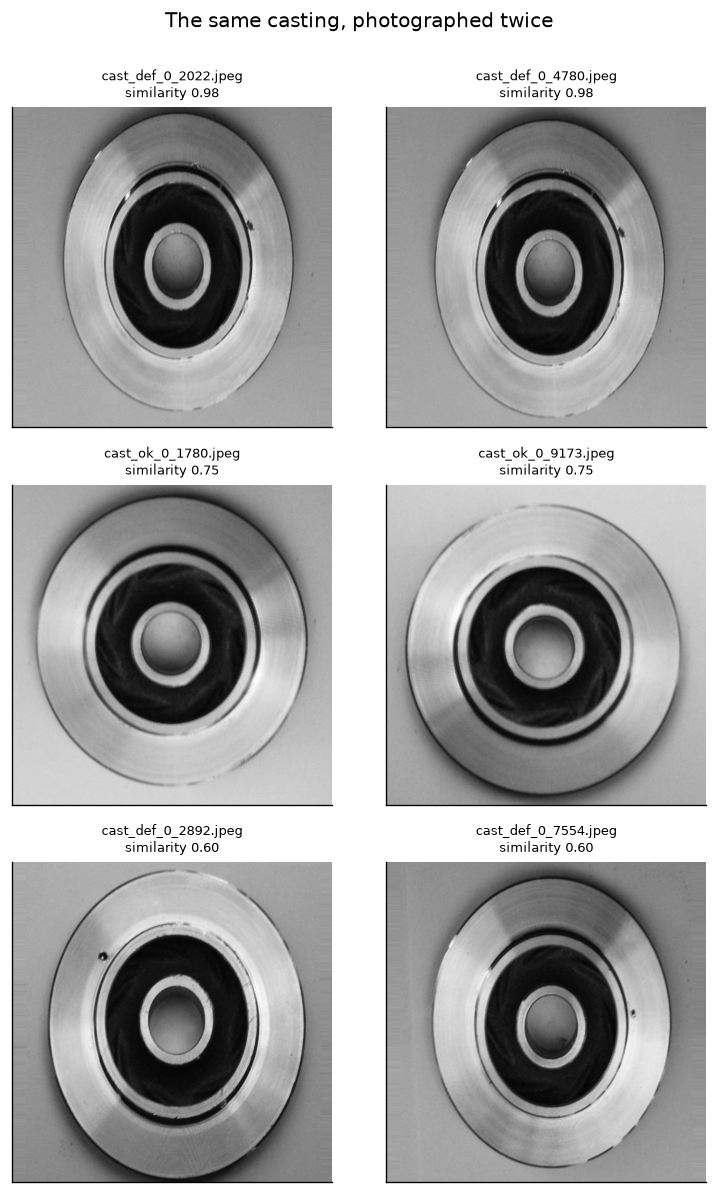

In [5]:
cleaned = cleaned.assign(group=duplicate_groups(similarity))
pairs = similar_pairs(similarity, cleaned["filename"], cleaned["label"])
group_sizes = cleaned["group"].value_counts()
print(f"{len(pairs)} matched pairs; {int((group_sizes > 1).sum())} castings photographed more than once, "
      f"covering {int(group_sizes[group_sizes > 1].sum())} images; largest group {int(group_sizes.max())}")
print("group size distribution:", group_sizes.value_counts().sort_index().to_dict())
display(pairs[pairs["first_label"] != pairs["second_label"]])

path_of = cleaned.set_index("filename")["path"]
fig = plot_duplicate_pairs(pairs.iloc[[0, len(pairs) // 2, len(pairs) - 1]], path_of, load_grayscale,
                           config.DUPLICATE_EXAMPLES)
plt.show()
save_figure(fig, "duplicate_pairs", "cleaning")

**More than half the dataset is the same castings photographed repeatedly:** 249 castings appear in two or more photographs, 721 of the 1,300 images belong to such a group, and the most common case is a pair (156 groups), with a long tail up to one chain of 32. The example pairs above are the same part at different rotations, with the same marks.

The one cross-label pair (`cast_def_0_6173` and `cast_ok_0_3064`, similarity 0.62) sits just above the threshold and is either a false match or a labeling error. It is kept rather than dropped: grouping it only means both photographs land in the same partition, which costs nothing.

These photographs are not removed. Each is a genuine image, and deleting all but one per casting would throw away 472 photographs to fix a problem that only exists at the split. The fix belongs there, and in every cross-validation that follows.

## 5. Three partitions

The brief fixes the proportions: 30% to understand the images, 30% to choose between approaches, 40% opened once at the end. Two splits are built from the same cleaned inventory so the cost of ignoring section 4 can be measured: a plain stratified split, and the group-aware split that is actually used. `StratifiedGroupKFold` cuts the data into ten folds that keep every group of photographs whole while balancing the class mix, and the folds are dealt out three, three and four.

In [6]:
naive = split_inventory(cleaned)
leaked = cross_partition_pairs(pairs, partition_of(*naive))
exposed = images_with_a_twin_in(pairs, partition_of(*naive), target="test", source="explore")
print(f"plain stratified split: {len(leaked)} matched pairs straddle two partitions; "
      f"{len(exposed)} test images have a twin in the training partition")

explore, validation, test = split_inventory(cleaned, cleaned["group"])
print(f"group-aware split: {len(cross_partition_pairs(pairs, partition_of(explore, validation, test)))} "
      "pairs straddle two partitions")
display(split_summary(explore, validation, test))

plain stratified split: 444 matched pairs straddle two partitions; 128 test images have a twin in the training partition
group-aware split: 0 pairs straddle two partitions


,partition,images,share_%,defective_%,ok_%
0,explore,390,30.0,60.0,40.0
1,validation,390,30.0,60.0,40.0
2,test,520,40.0,60.2,39.8


**A plain stratified split would have leaked badly:** 444 matched pairs would straddle two partitions, and 128 of the 520 test images would have a photograph of the same casting in the training partition. That is a quarter of the test set measuring recognition of parts the model had already seen, and no accuracy number would reveal it.

**The group-aware split leaks nothing** (0 pairs cross a boundary) and still lands exactly on the brief's proportions: 390 / 390 / 520 images, 30 / 30 / 40%, with the 60/40 class balance in every partition. The group ids travel with the images, so every cross-validation below keeps each casting's photographs together too.

## 6. Exploring the images

Everything from here to section 12 uses the exploration and validation partitions only. The test partition is next read in section 13.

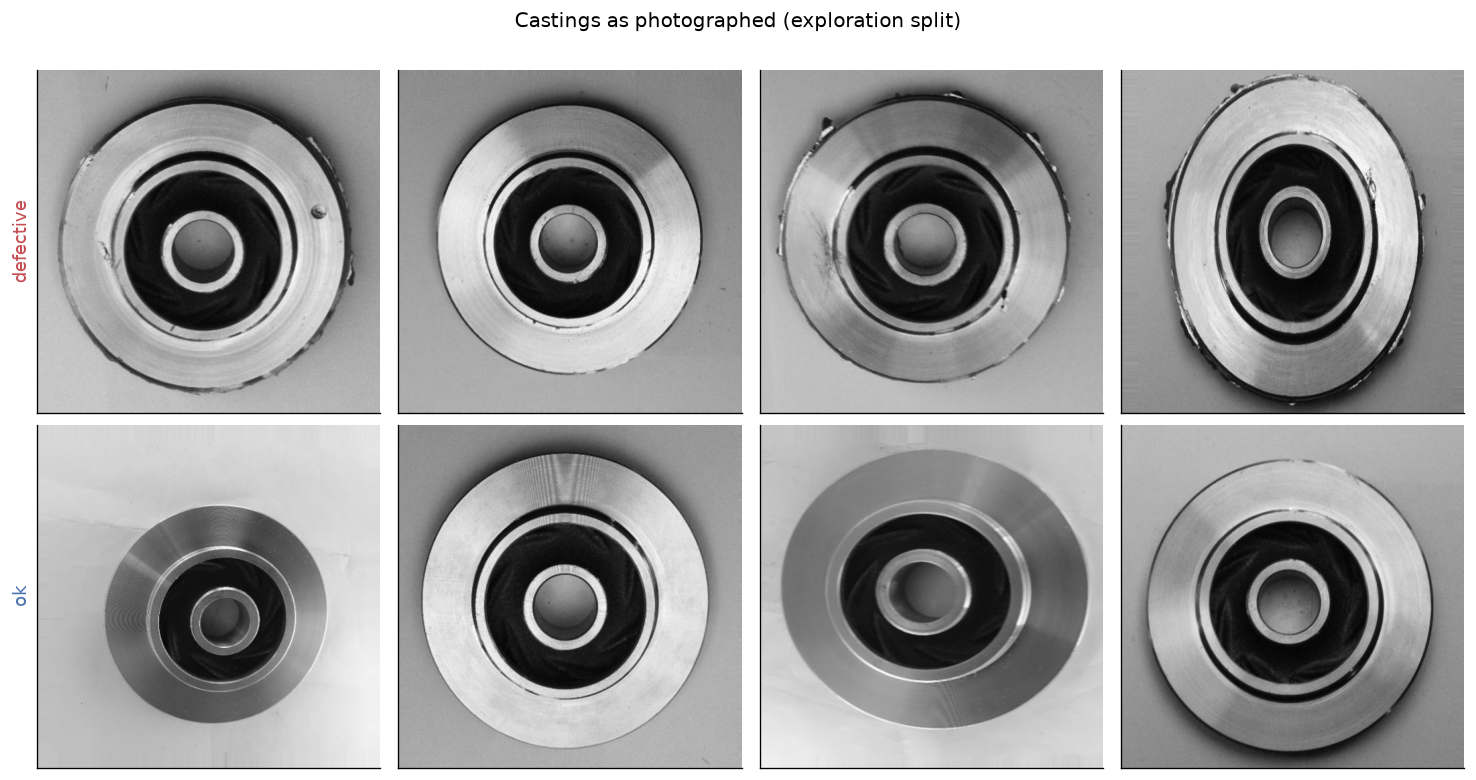

In [7]:
paths_by_class = {label: explore.loc[explore["label"] == label, "path"].head(config.SAMPLE_GRID_PER_CLASS).tolist()
                  for label in (config.DEFECT, config.OK)}
fig = plot_sample_grid(paths_by_class, load_grayscale, config.SAMPLE_GRID_PER_CLASS)
plt.show()
save_figure(fig, "samples", "eda")

**Looking before measuring shaped the design:** every casting is the same part: a bright machined outer rim, a near-black vane cavity, a bright bore collar and a gray hub. The background is a light workbench, not the dark field a casting photograph is usually assumed to have. The defects are visible as dark chips, pits and rough patches on the bright rim, and in the worst cases as burrs and flash spilling past the part's edge. The rim is where the inspection has to look.

label                        0        1
sharpness       count  156.000  234.000
                mean     0.004    0.004
                std      0.002    0.002
                min      0.001    0.001
                25%      0.001    0.003
                50%      0.003    0.004
                75%      0.005    0.005
                max      0.009    0.015
noise_sigma     count  156.000  234.000
                mean     0.341    0.409
                std      0.104    0.068
                min      0.099    0.185
                25%      0.253    0.389
                50%      0.346    0.420
                75%      0.438    0.438
                max      0.524    0.698
band_brightness count  156.000  234.000
                mean   140.489  154.258
                std     21.073   19.990
                min    108.984   94.383
                25%    123.426  141.464
                50%    133.784  159.491
                75%    156.212  168.651
                max    192.619  194.033
band_contrast   count  156.000  234.000
                mean    42.037   47.941
                std      6.625    7.159
                min     33.081   31.448
                25%     36.051   43.894
                50%     40.084   48.202
                75%     47.119   51.830
                max     59.426   68.718

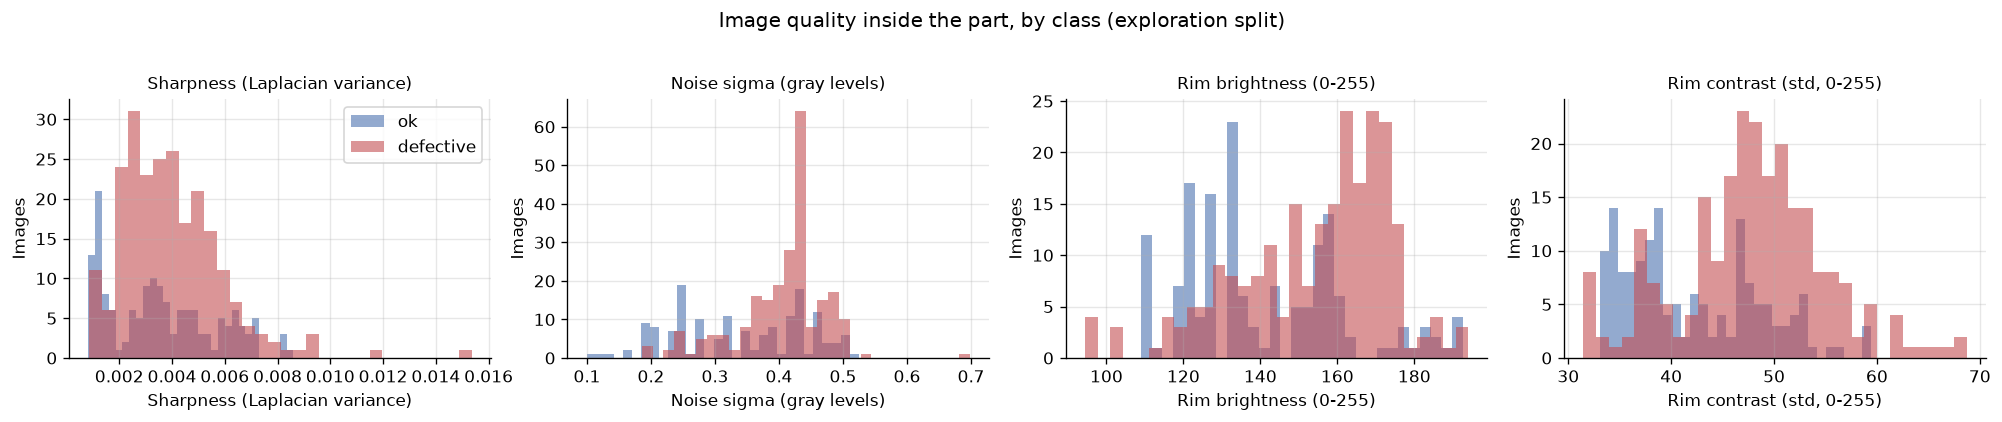

In [8]:
quality = quality_batch(explore, load_grayscale)
metrics = {"sharpness": "Sharpness (Laplacian variance)", "noise_sigma": "Noise sigma (gray levels)",
           "band_brightness": "Rim brightness (0-255)", "band_contrast": "Rim contrast (std, 0-255)"}
display(quality.groupby("label")[list(metrics)].describe().T.round(3))
fig = plot_quality_by_class(quality, metrics)
plt.show()
save_figure(fig, "quality_by_class", "eda")

**Image quality differs between the classes inside the part, not only outside it:** sharpness overlaps almost completely (median Laplacian variance 0.003 against 0.004). Noise does not: the estimated noise sigma is higher for defective photographs (median 0.42 gray levels against 0.35), and so are rim brightness (mean 154 against 140) and rim contrast (48 against 42). Some of that is the defects themselves, since pits and chips add contrast, but the brightness gap is the kind of difference a different exposure produces. It is one reason every intensity feature is normalized by the rim's own median, and one reason section 12 tests what exposure and compression changes do to the decisions.

### The lighting confound

The four corners of each image contain workbench and nothing else: no casting, no defect. If their brightness separates the classes, a classifier could score well by reading the lamp.

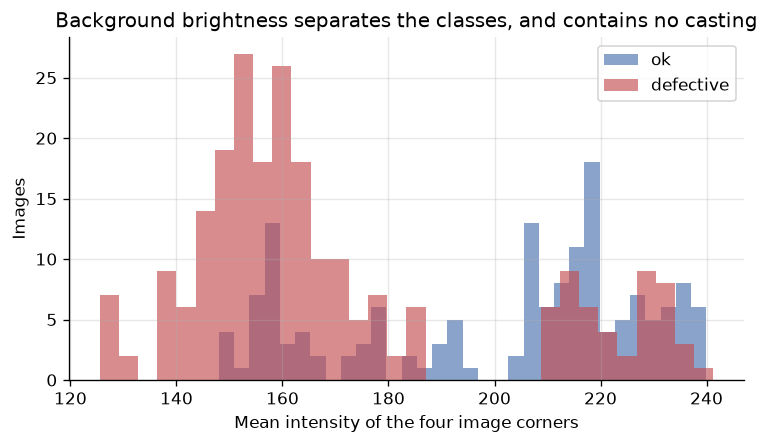

,feature,higher_in,separation_all
0,nuisance_background_mean,ok,0.772
1,nuisance_corner_mean,ok,0.767
2,nuisance_background_std,defective,0.669


In [9]:
explore_features = describe_batch(explore, load_grayscale, include_nuisance=True)
nuisance = [c for c in explore_features.columns if c.startswith("nuisance_")]
fig = plot_confound(explore_features)
plt.show()
save_figure(fig, "confound", "eda")
display(separation_table(explore_features, nuisance))

**The two folders were not photographed under the same light:** defective castings sit on a darker workbench, and the three background probes separate the classes with no metal in view: the background ring's mean at 0.772, the four corners at 0.767, and the background's spread at 0.669 (max(AUC, 1 - AUC) on the exploration split).

This single measurement reshapes the rest of the project:

- Every model feature is computed strictly inside the part, and the test suite enforces it by repainting the background and requiring each feature to stay put.
- The honest baseline is not the 60% majority class. It is what a classifier reaches from background pixels alone, the "background floor" in section 11.
- One accuracy number cannot show that the model inspects metal, so section 11 includes an exposure-matched control where the lighting shortcut is unavailable by construction.

## 7. Locating the part

**Why Otsu fails here:** Otsu's method picks the gray level that maximizes the between-class variance of the histogram, equivalently the split that makes the two sides as internally uniform as possible. It is exact when the histogram has one mode for the object and one for the background. A casting photograph is usually a bright part on a dark field, which suits it. These images are the other way round: the workbench is light, the machined faces are brighter still, and only the vane cavity is dark. The measurement below is the share of the frame taken by the largest component above the Otsu threshold, which should be the part.

In [10]:
otsu = [otsu_largest_share(load_grayscale(path)) for path in explore["path"].head(config.OTSU_CHECK_SAMPLE)]
print(f"largest Otsu component, share of the frame over {len(otsu)} images: "
      f"min {min(otsu):.0%}, median {np.median(otsu):.0%}, max {max(otsu):.0%}")
print(f"cavity anchor found in {int(quality['anchor_found'].sum())}/{len(quality)} exploration images")
print(f"center: row {quality['anchor_row'].mean():.0f} +/- {quality['anchor_row'].std():.0f} px, "
      f"col {quality['anchor_col'].mean():.0f} +/- {quality['anchor_col'].std():.0f} px")
print(f"cavity radius: {quality['anchor_radius'].mean():.0f} +/- {quality['anchor_radius'].std():.0f} px")
print("cavity axis ratio (1.0 is a circle), percentiles 1/5/50:",
      np.round(np.percentile(quality["anchor_axis_ratio"], [1, 5, 50]), 3))

largest Otsu component, share of the frame over 60 images: min 36%, median 74%, max 80%
cavity anchor found in 390/390 exploration images
center: row 255 +/- 13 px, col 256 +/- 11 px
cavity radius: 101 +/- 7 px
cavity axis ratio (1.0 is a circle), percentiles 1/5/50: [0.792 0.834 0.936]


**Otsu fails exactly as predicted:** the component that should be "the part" covers 74% of the frame at the median and up to 80%, because the threshold joins the bright rim to the bright workbench. The minimum of 36% is a photograph where the join broke, which is no better, just wrong in a different way.

**The cavity anchor works everywhere:** thresholding for the darkest large object, after an opening that removes dark speckle, finds the vane cavity in all 390 exploration images. Its center sits within about 12 pixels of the frame center and its radius is 101 +/- 7 px. Every later measurement is expressed in units of this radius, so the pipeline follows the part if it is photographed nearer to or further from the camera. The cavity is not a perfect circle even from above (median axis ratio 0.94, 5th percentile 0.83), which matters when section 13 asks whether a tilted photograph could be detected from it.

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
radius,0.06,0.18,0.29,0.41,0.52,0.64,0.76,0.87,0.99,1.11,...,1.69,1.81,1.92,2.04,2.16,2.27,2.39,2.51,2.62,2.74
defective,106.90,100.80,89.10,79.40,144.90,62.20,19.70,21.70,21.20,34.70,...,159.00,158.80,157.20,146.30,137.50,147.80,157.90,164.30,168.10,170.20
ok,105.30,99.90,88.30,84.00,139.20,83.40,24.60,24.50,24.60,31.70,...,147.50,148.10,148.50,149.90,152.70,170.60,183.10,187.50,190.20,192.20


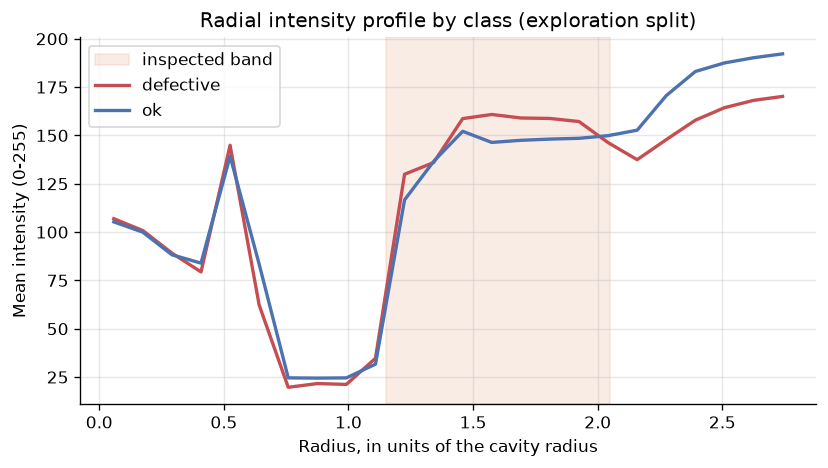

In [11]:
profiles, edges = class_profiles(explore, load_grayscale, config.PROFILE_SAMPLE_PER_CLASS)
centers = (edges[:-1] + edges[1:]) / 2
display(pd.DataFrame({"radius": centers.round(2), **{k: v.round(1) for k, v in profiles.items()}}).T)
fig = plot_radial_profile(profiles, edges, (config.RIM_INNER_FACTOR, config.RIM_OUTER_FACTOR))
plt.show()
save_figure(fig, "radial_profile", "eda")

**The profile places every stage of the pipeline:** from the center outward: the gray hub, the near-black cavity from about 0.7 to 1.0 cavity radii (20 to 25 gray levels), the bright machined rim from about 1.2 to 2.0, and then the part's edge. The inspected band (shaded) is bounded at 1.15 and 2.05 because that is where the machined surface is.

Past 2.1 radii the two curves separate: at 2.16 radii the sound average is 153 against 138 for defective, and at 2.74 it is 192 against 170, a 15 to 22 level gap that keeps widening toward the corners. That region is workbench, and the gap is the lighting confound seen from a second angle.

## 8. The inspection pipeline

Each stage is there because of something the images do.

**Median filter, 3x3:** a median replaces each pixel with the middle value of its window. An isolated speck of grain or JPEG noise is an extreme of its window and is discarded outright, while a step edge survives because the middle value on each side is still that side's level. A Gaussian is a weighted average: it cannot discard an outlier, only spread it, and it rounds every edge. The edge of a chip is the signal, so the median is the filter that keeps it. Section 10 tests this claim rather than assuming it.

**Restrict to the machined band:** from 1.15 to 2.05 cavity radii, placed by the radial profile. No model feature reads anything outside it.

**Normalize by the band's own median:** dividing every pixel by the median of the band makes a feature measure how a pixel compares to the metal beside it, not how bright the photograph was. A pure change of exposure multiplies every pixel by one factor and cancels exactly; section 12 measures the changes it cannot cancel.

**Isolate:** before any operator with a spatial footprint runs, everything outside the band is replaced with the band's median, so no neighborhood reaches into the confounded background.

**Black top-hat at radii 5, 11 and 21:** closing is a dilation (local maximum) followed by an erosion (local minimum) with the same structuring element, and it fills any dark feature too small for the element to fit inside while leaving larger regions and all bright structure alone. The closing minus the image is exactly the amount filled in: how much darker a pixel is than the metal around it, at that scale. A blow hole or a chip is precisely that, and a slow lighting gradient is not a pit at any scale, so it produces no response. Three radii cover pin holes to shrinkage cavities, and the pixelwise maximum keeps whichever responded.

**Polar unwrapping:** the rim is resampled to 360 angles by 64 radii. A rotation of the part becomes a cyclic shift of the rows, so any statistic that ignores the shift is rotation-invariant by construction.

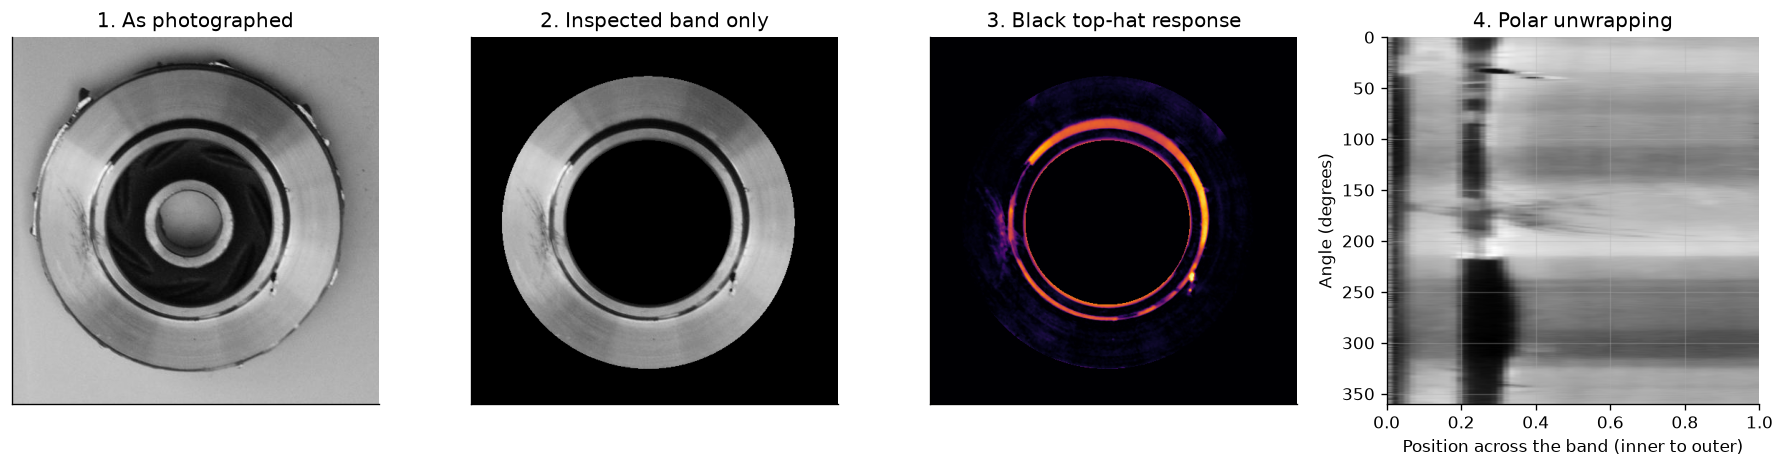

In [12]:
example = load_grayscale(explore.loc[explore["label"] == config.DEFECT, "path"].iloc[2])
stages = pipeline_stages(example)
fig = plot_pipeline_stages(example, stages.band, stages.response, unwrap(stages.isolated, stages.anchor))
plt.show()
save_figure(fig, "pipeline_stages", "pipeline")

The response map (panel 3) lights up the rough, scratched patch on the left of the rim and a small chip at the lower right. It is dominated, though, by the dark groove that runs around every casting just outside the cavity: a groove is locally darker than the metal beside it, so the top-hat responds to it on sound castings too. That ring comes back in section 14. The burrs on this casting's outer edge lie outside the band and are never measured. The polar unwrapping (panel 4) shows the same rim with rotation turned into a vertical shift: the groove is the dark vertical stripe, and the rough patch is the disturbance between about 150 and 200 degrees.

## 9. What separates the classes

Features come in six families, all measured inside the band on the normalized image:

- **Top-hat response** (mean, spread, 95th and 99th percentile, maximum): how deep and how common the pits are.
- **Sobel gradient:** Sobel is a 3x3 derivative, a central difference across one direction smoothed along the other, applied in both directions and combined into a magnitude. It is large where intensity changes fast, as it does at the rim of a chip and across a rough surface.
- **Normalized intensity** statistics.
- **Angular wedges:** the unwrapped rim averaged down each angle and smoothed with a wrapped window one twelfth of a turn wide. A chip barely moves the mean of the whole ring but dominates its own wedge, and order statistics of a cyclically shifted profile do not change, so these are rotation-invariant.
- **Rotation-invariant uniform LBP:** for each pixel, the 8 neighbors on a radius-1 circle are compared with it and each comparison becomes one bit. A code is uniform when the circular bit string changes between 0 and 1 at most twice; those codes are flat patches, edges, lines and corners, the large majority on real surfaces. Taking the minimum over all circular rotations of the bit string removes orientation, leaving 9 uniform classes, numbered by how many neighbors are brighter than the center, plus one bin for everything non-uniform. The band's histogram over those 10 bins describes its texture: a pitted surface moves weight from the flat bins into the edge and corner bins.
- **Response blobs and areas:** how much of the band responded above three severities, and how many connected blobs formed.

Section 6 showed the lighting differs between the folders, so each feature's separation is measured twice: on all exploration images, and on an exposure-matched subset where every sound casting is paired with a defective one photographed within one gray level of the same corner brightness.

36 model features, 3 background probes kept out of every model
exposure-matched pairs within explore: 84


,feature,higher_in,separation_all,separation_matched,confound_share
0,tophat_max,defective,0.842,0.709,0.133
1,response_area_5,defective,0.596,0.689,-0.093
2,lbp_4,defective,0.713,0.688,0.025
3,lbp_5,defective,0.716,0.676,0.040
4,lbp_7,ok,0.635,0.675,-0.040
5,response_area_10,defective,0.566,0.669,-0.103
6,blob_count,defective,0.534,0.660,-0.126
7,blob_total_area,defective,0.516,0.659,-0.143
8,lbp_8,ok,0.620,0.641,-0.021
9,response_area_20,defective,0.590,0.618,-0.028


,feature,higher_in,separation_all,separation_matched,confound_share
24,nuisance_background_std,defective,0.669,0.534,0.135
35,nuisance_corner_mean,ok,0.767,0.506,0.261
38,nuisance_background_mean,ok,0.772,0.500,0.272


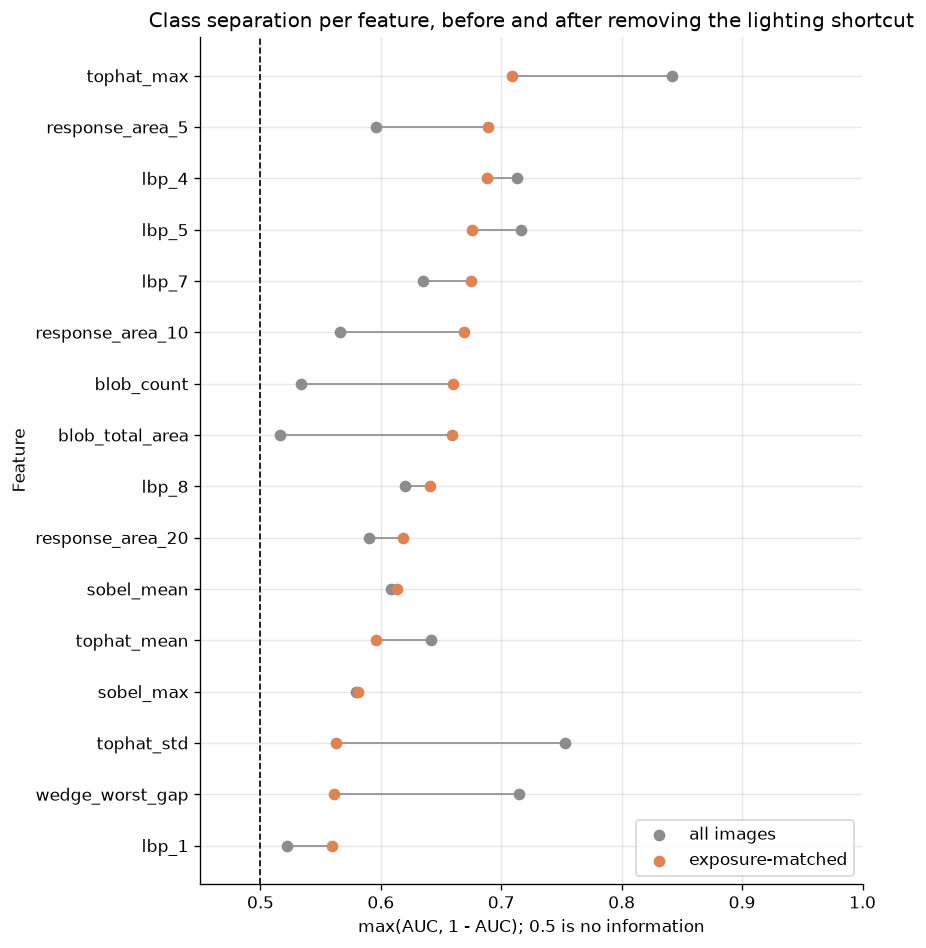

In [13]:
validation_features = describe_batch(validation, load_grayscale, include_nuisance=True)
columns = feature_columns(explore_features)
print(f"{len(columns)} model features, {len(nuisance)} background probes kept out of every model")

explore_matched = exposure_matched_pairs(explore_features)
separation = separation_table(explore_features, columns + nuisance, explore_matched)
print(f"exposure-matched pairs within explore: {len(explore_matched) // 2}")
display(separation.head(16))
display(separation[separation["feature"].isin(nuisance)])
fig = plot_feature_separation(separation, top=16)
plt.show()
save_figure(fig, "feature_separation", "features")

**The matched column is the one to read:** within the exploration split, 84 sound castings could be paired with a defective one photographed within one gray level of the same corner brightness. The second table is the check that the matching worked: the three background probes fall from 0.77 to between 0.50 and 0.53, essentially no information. Whatever separation a feature keeps on that subset comes from the metal.

- **The top-hat maximum stays the strongest single feature** (0.842 on all images, 0.709 matched): the depth of the worst pit is real signal, and some of its apparent power was lighting.
- **LBP texture holds up best:** `lbp_4` and `lbp_5`, the middle uniform codes that mark edges and ridges, lose almost nothing (0.713 to 0.688 and 0.716 to 0.676). Texture is measured relative to each pixel's own neighbors, so exposure largely cancels.
- **Some features lean on the shortcut:** `tophat_std` falls from 0.753 to 0.563 and `wedge_worst_gap` from 0.715 to 0.561, so most of what they showed was lighting.
- **Response-area and blob counts gain under matching** (for example `blob_count` 0.534 to 0.660). With the lighting held equal, the amount of surface that responds becomes a clearer signal rather than a weaker one.

The `higher_in` column records direction: `lbp_7`, `lbp_8` and `sobel_max` are higher on sound castings, and ranking by max(AUC, 1 - AUC) keeps them where their strength puts them instead of sinking them to the bottom.

## 10. Design decisions, each tested

Three choices made earlier are checked here on the exploration and validation splits, each against the alternative it replaced.

### A hand-built rule, and what the first version got wrong

A hand-built rule runs anywhere, needs no model file, and lets a line worker be told exactly what caused a rejection. The obvious construction is an **OR of alarms**: one per feature, each set at the 97.5th percentile of sound castings, rejecting the part if any fires. The replacement is a **weighted score**: each of five named features standardized on the exploration split, averaged, and compared with one threshold chosen there to maximize defect-class F1.

In [14]:
y_explore, y_validation = explore_features["label"].to_numpy(), validation_features["label"].to_numpy()
gates = fit_or_gate(explore_features, y_explore)
rule = fit_rule(explore_features, y_explore)
print("rule features:", ", ".join(rule["columns"]), f"| threshold {rule['threshold']:+.2f}")
display(pd.DataFrame([
    {"design": "OR of per-feature alarms", **evaluate(y_validation, apply_or_gate(validation_features, gates))},
    {"design": "weighted score, one threshold", **evaluate(y_validation, apply_rule(validation_features, rule))},
]).round(3))

rule features: tophat_max, tophat_p95, response_area_10, sobel_mean, wedge_worst_gap | threshold -0.85


,design,accuracy,f1_defect,recall_defect,precision_defect,missed_defects,false_alarms
0,OR of per-feature alarms,0.664,0.649,0.517,0.871,113,18
1,"weighted score, one threshold",0.718,0.810,1.000,0.680,0,110


**The first design failed in a specific way:** the OR of per-feature alarms caught only 52% of defects (113 missed on validation): each alarm is set high enough to stay quiet on 97.5% of sound parts, and a defective casting usually moves several features a little rather than one feature a lot. The defect signal on this dataset is graded, not outlying.

**The weighted score fixes that and overshoots the other way:** averaging five standardized features lets small shifts add up, so it misses nothing on validation (recall 1.000), but its F1-optimal threshold rejects 110 of 156 sound parts. Its accuracy of 0.718 sits below the background floor in section 11, which is why that floor had to be measured: a simple honest detector loses to a dishonest one that reads the lamp.

### Median against Gaussian

The pipeline's first filter is a 3x3 median, argued for in section 8. The alternative is a Gaussian of comparable footprint (sigma 1). Both pipelines are featurized, the same SVM is tuned on each by the same group-aware cross-validation, and each is scored on validation. Exactly one thing differs.

In [15]:
prefilter_rows = []
for method in ("median", "gaussian"):
    train = explore_features if method == "median" else describe_batch(explore, load_grayscale, method=method)
    valid = validation_features if method == "median" else describe_batch(validation, load_grayscale, method=method)
    model, grid = build_models()["svm_rbf"]
    search = tune(model, grid, train[columns], train["label"], train["group"])
    prefilter_rows.append({"prefilter": method, "cv_f1_explore": search.best_score_,
                           **evaluate(y_validation, search.predict(valid[columns]))})
display(pd.DataFrame(prefilter_rows).round(3))

,prefilter,cv_f1_explore,accuracy,f1_defect,recall_defect,precision_defect,missed_defects,false_alarms
0,median,0.975,0.967,0.973,0.996,0.951,1,12
1,gaussian,0.978,0.933,0.945,0.957,0.933,10,16


**The median earns its place:** with the Gaussian prefilter the tuned SVM misses 10 defects on validation instead of 1 and raises 16 false alarms instead of 12, so F1 falls from 0.973 to 0.945. The mechanism argued in section 8 shows up in the misses: blurring rounds the edge of a chip and spreads a pit's darkness into the metal around it, which is exactly what the top-hat and LBP measure.

Cross-validation on the exploration split could not tell the two apart (0.975 against 0.978), and validation could. That is the reason a separate validation partition exists: a within-sample score can miss a real difference in how a choice generalizes.

### A speed decision checked, not assumed

The top-hat at radius 21 dominated the first version's run time. Grayscale dilation and erosion take a maximum or minimum over every pixel under the element, so a plain radius-21 disk costs 1,373 comparisons per output pixel. Dilating by A and then by B equals dilating once by their Minkowski sum, so the disk can be replaced by a short sequence of 3x3 elements whose sum is an octagon. The cost then scales with the radius instead of its square. The octagon is not the disk, so the check below measures both the speed and how far the response moves.

In [16]:
display(pd.Series(decomposition_check(explore["path"].head(config.DECOMPOSITION_CHECK_SAMPLE), load_grayscale)))

images                    8.00
plain_ms               1432.60
decomposed_ms           111.70
speedup                  12.80
max_peak_change_%         0.00
mean_pixel_change_%       1.28
dtype: float64

**The decomposition is 12.8 times faster and changes almost nothing:** the three-radius top-hat drops from 1,433 ms to 112 ms per image, the band's peak response is unchanged on every image checked, and the average pixel moves by 1.3% of the mean response. That is the single change that made the pipeline fast enough to time as a product, and it was kept because this check says it costs nothing.

## 11. Learned classifiers

Two classical models over the full feature vector.

**Random forest:** a few hundred decision trees, each grown on a bootstrap resample of the training images and allowed to consider only a random subset of features at each split. A single deep tree memorizes its sample; averaging many decorrelated trees keeps their ability to model interactions while the random resampling and feature subsets cancel much of the variance. The prediction is the majority vote. Trees split on one feature at a time, so the forest needs no feature scaling.

**SVM with an RBF kernel:** a support vector machine finds the boundary with the widest margin between the classes, determined only by the training points nearest to it (the support vectors). The RBF kernel `exp(-gamma * ||x - x'||^2)` lets that boundary be curved: it measures similarity by distance, so the decision for a new casting is a weighted vote of the support vectors near it. `gamma` sets how near "near" is (large gamma, very local and wiggly boundaries), and `C` sets how much a training point on the wrong side is penalized against the width of the margin (large C, fewer training errors, more risk of overfitting). Because the kernel works on Euclidean distance, features must be on comparable scales, so the SVM's scaler is fitted inside its pipeline on each fold's training part only.

**Tuning is group-aware:** hyperparameters are chosen by 5-fold cross-validation on the exploration split, with folds that keep every casting's photographs together. The exploration split holds several photographs of some castings, and a fold that trained on one and scored another would reward memorization.

**Augmentation:** each model is also trained on the exploration images plus four augmented copies of each. Every copy applies, each with probability one half, a rotation to any angle, a tone curve with gamma between 0.85 and 1.15, and JPEG re-encoding at quality 40 to 90. These are changes a photograph can undergo without the casting changing, so the model should not care about them. Copies stay in their source image's fold and are never scored.

The background floor is fitted first: the same random forest, on the three workbench probes alone. The winner is the learned model with the highest defect-class F1 on validation.

,model,accuracy,f1_defect,recall_defect,precision_defect,missed_defects,false_alarms,roc_auc
0,background floor,0.851,0.878,0.889,0.867,26,32,0.905
1,rule-based,0.718,0.810,1.000,0.680,0,110,0.793
2,random_forest,0.959,0.967,0.991,0.943,2,14,0.989
3,svm_rbf,0.967,0.973,0.996,0.951,1,12,0.961
4,random_forest + augmentation,0.969,0.975,0.987,0.962,3,9,0.992
5,svm_rbf + augmentation,0.979,0.983,0.991,0.975,2,6,0.970


random_forest                  settings {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}  group-aware CV F1 on explore 0.943
svm_rbf                        settings {'model__C': 100.0, 'model__gamma': 0.03}  group-aware CV F1 on explore 0.975
random_forest + augmentation   settings {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 400}  group-aware CV F1 on explore 0.951
svm_rbf + augmentation         settings {'model__C': 10.0, 'model__gamma': 0.1}  group-aware CV F1 on explore 0.983


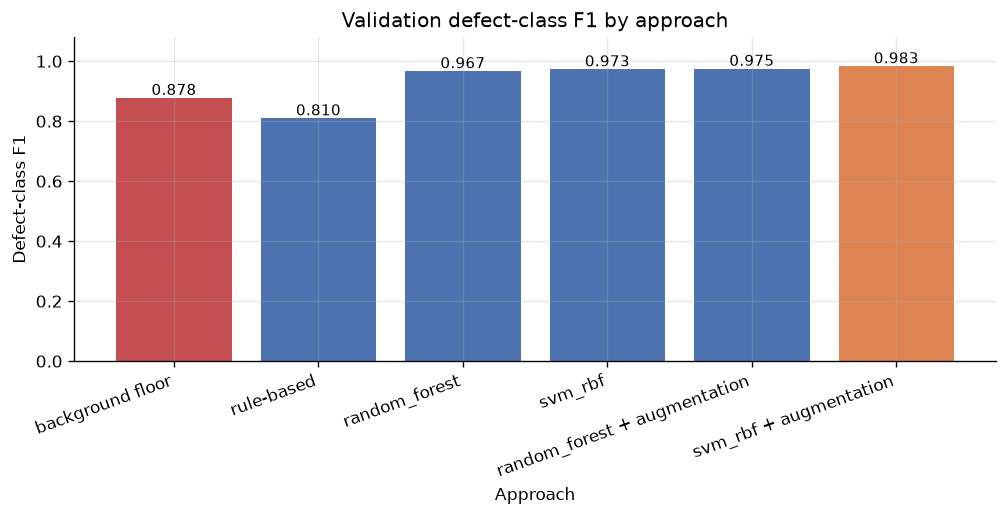

In [17]:
explore_augmented = augment_batch(explore, load_grayscale)
board, fitted = compare_models(explore_features, validation_features, columns, nuisance, rule, explore_augmented)
display(board.round(3))
for name, search in fitted.items():
    print(f"{name:<30} settings {search.best_params_}  group-aware CV F1 on explore {search.best_score_:.3f}")
fig = plot_model_comparison(board)
plt.show()
save_figure(fig, "model_comparison", "modeling")

**Every learned model clears the background floor by a wide margin:** the forest on three workbench probes reaches 0.851 accuracy and 0.878 F1 on validation without looking at any metal. That is the bar.

**Augmentation improves both models on clean validation images,** before robustness is even considered: the SVM goes from F1 0.973 to 0.983 and from 12 false alarms to 6, the forest from 0.967 to 0.975 and from 14 to 9. Seeing each training casting under several rotations, tone curves and compression levels teaches the model which feature changes are photography rather than metal.

**The SVM with augmentation wins on the declared metric** (F1 0.983, 2 missed defects, 6 false alarms out of 156 sound castings). Its group-aware cross-validation chose C = 10 and gamma = 0.1, both inside the grid (C ran from 0.1 to 1000, gamma from 0.003 to 1). One nuance: the forest ranks castings better overall (ROC AUC 0.992 against 0.970), so the SVM wins at its default threshold, not across every threshold. That matters if the factory later moves the threshold, and the operating-point table below shows what moving it costs.

The cross-validation scores are group-aware, so they cannot be inflated by a fold that trains on one photograph of a casting and scores another; section 5 counted 444 such pairs a plain split would have created.

In [18]:
winner = board[board["model"].isin(fitted)].sort_values("f1_defect").iloc[-1]["model"]
shipped = fitted[winner]
runner_up = board[board["model"].isin(fitted) & (board["model"] != winner)].sort_values("f1_defect").iloc[-1]["model"]
print(f"validation winner on defect-class F1: {winner}; runner-up: {runner_up}")

combined = pd.concat([explore_features.assign(augmented=False), explore_augmented], ignore_index=True)
training = combined if winner.endswith("augmentation") else explore_features.assign(augmented=False)
spread = {name: repeated_cv(fitted[name].best_estimator_, training[columns], training["label"],
                            training["group"], ~training["augmented"]) for name in (winner, runner_up)}
display(pd.DataFrame({name: {"mean F1": s.mean(), "sd": s.std(), "min": s.min(), "max": s.max()}
                      for name, s in spread.items()}).T.round(3))
print("McNemar exact test on validation, winner vs runner-up:",
      mcnemar_exact(y_validation, shipped.predict(validation_features[columns]),
                    fitted[runner_up].predict(validation_features[columns])))

validation winner on defect-class F1: svm_rbf + augmentation; runner-up: random_forest + augmentation


,mean F1,sd,min,max
svm_rbf + augmentation,0.982,0.023,0.896,1.0
random_forest + augmentation,0.948,0.054,0.781,1.0


McNemar exact test on validation, winner vs runner-up: {'only_first_right': 5, 'only_second_right': 1, 'p_value': 0.21875}


**The SVM's lead is consistent but not proven:** over 25 repeated group-aware splits of the augmented exploration data, the SVM averages F1 0.982 (sd 0.023) against the forest's 0.948 (sd 0.054), and the SVM is also the steadier of the two. On validation the two disagree on 6 images, the SVM right on 5 of them, and an exact McNemar test gives p = 0.22. The SVM ships because it was named the winner on defect-class F1 before the test set was opened and because its cross-validation is both higher and tighter, not because the difference is statistically established.

### How much one split can move the error rates

The validation partition is one draw of castings. To see how much the error rates depend on which castings land in the held-out set, the shipped configuration is refit over repeated group-aware folds of the whole development set (exploration plus validation, 780 images), with augmented copies for the training side of each fold. The test partition is not touched.

In [19]:
validation_augmented = augment_batch(validation, load_grayscale)
development = pd.concat([explore_features, validation_features], ignore_index=True).assign(augmented=False)
if winner.endswith("augmentation"):
    development = pd.concat([development, explore_augmented, validation_augmented], ignore_index=True)
rates = grouped_cv_rates(shipped.best_estimator_, development[columns], development["label"],
                         development["group"], ~development["augmented"])
display(rates.describe().loc[["mean", "std", "min", "max"]].round(3))

,accuracy,recall_defect,false_alarm_rate,f1_defect
mean,0.991,0.994,0.013,0.992
std,0.016,0.010,0.032,0.013
min,0.942,0.968,0.000,0.952
max,1.000,1.000,0.097,1.000


**One partition can move the false-alarm rate a lot:** over 25 group-aware folds of the 780 development images, the shipped configuration averages 99.1% accuracy (sd 1.6%), 99.4% recall and a 1.3% false-alarm rate, but the false-alarm rate of a single fold ranges from 0% to 9.7%. Validation's 3.8% (6 of 156) sits inside that range, and so does whatever the test set shows. A difference between two partitions of a few castings is expected, not alarming.

### The operating point

The SVM's decision is the sign of its margin. Moving the threshold trades missed defects for false alarms, which is a business decision rather than a modeling one. The table shows the dial on validation; the shipped threshold stays at zero.

In [20]:
display(operating_points(y_validation, decision_scores(shipped, validation_features[columns])))

,threshold,rejected,missed_defects,false_alarms,recall_defect,precision_defect
0,-1.0,274,0,40,1.000,0.854
1,-0.5,243,2,11,0.991,0.955
2,0.0,238,2,6,0.991,0.975
3,0.5,220,20,6,0.915,0.973
4,1.0,155,85,6,0.637,0.961


**The default threshold is a good place to sit:** lowering it to -0.5 adds 5 false alarms and catches no extra defect. Catching the last 2 defects on validation needs -1.0 and raises false alarms from 6 to 40, a quarter of the sound parts sent for re-inspection: 34 extra re-inspections, about 17 per defect caught. Raising it to 0.5 lets 20 defects through without removing a single false alarm. Unless a missed defect costs more than about 17 re-inspections, the threshold stays at zero.

### The control: does anything survive without the lighting shortcut?

The matched subset is 50/50 by construction and smaller than the full set, so comparing it with "all images" would change three things at once. The comparison below changes one: random subsets of exactly the same size and the same 50/50 balance, drawn 20 times, against the exposure-matched subset, with the shipped model's settings and the same group-aware cross-validation. Only the exposure matching differs.

In [21]:
development_matched = exposure_matched_pairs(development[~development["augmented"]])
control = matched_control(development[~development["augmented"]], development_matched,
                          shipped.best_estimator_, columns, nuisance)
display(control)

,subset,images,part_features,part_features_sd,background_features,background_features_sd
0,"random balanced, 20 draws",346,0.984,0.008,0.775,0.019
1,exposure-matched,346,0.971,NaN,0.477,NaN


**This is the result the project rests on:** on random balanced subsets of 346 development images, the shipped model's settings reach 0.984 accuracy from part features and 0.775 from the three background probes. On the exposure-matched subset of the same size, where corner brightness is equal between the classes by construction, the background probes fall to 0.477, which is chance, while the part features hold at 0.971. Only the exposure matching differs between the two rows, and both use group-aware folds.

Had the part-only score collapsed alongside the background score, the honest conclusion would have been that this dataset cannot be solved by inspecting castings. It did not collapse, so the classifier is reading metal.

## 12. Robustness to the photograph

Normalization cancels a pure change of exposure in theory. In practice 8-bit rounding, clipping and non-linear tone changes all move the features. The two versions of the winning model, with and without augmentation, are re-run on validation images after controlled changes to the photograph, and each decision is compared with the same model's decision on the unmodified image. The perturbations use fixed values chosen before looking, and validation rather than test is used so the sealed set stays opened once.

flipped                        false_alarms                        missed_defects                       
model        svm_rbf svm_rbf + augmentation      svm_rbf svm_rbf + augmentation        svm_rbf svm_rbf + augmentation
perturbation                                                                                                         
gain 0.9           4                      0            2                      2              3                      0
gain 1.1           4                      0            6                      2              1                      0
gamma 0.9         14                      3           10                      2              5                      3
gamma 1.1          5                      0            8                      2              0                      0
jpeg 50           21                      3           18                      3              4                      2
jpeg 75            0                      0            3                      2              0                      0
none               0                      0            3                      2              0                      0
rotate 10         14                      0           14                      2              1                      0
rotate 37         14                      1           16                      2              1                      1
rotate 90          0                      0            3                      2              0                      0

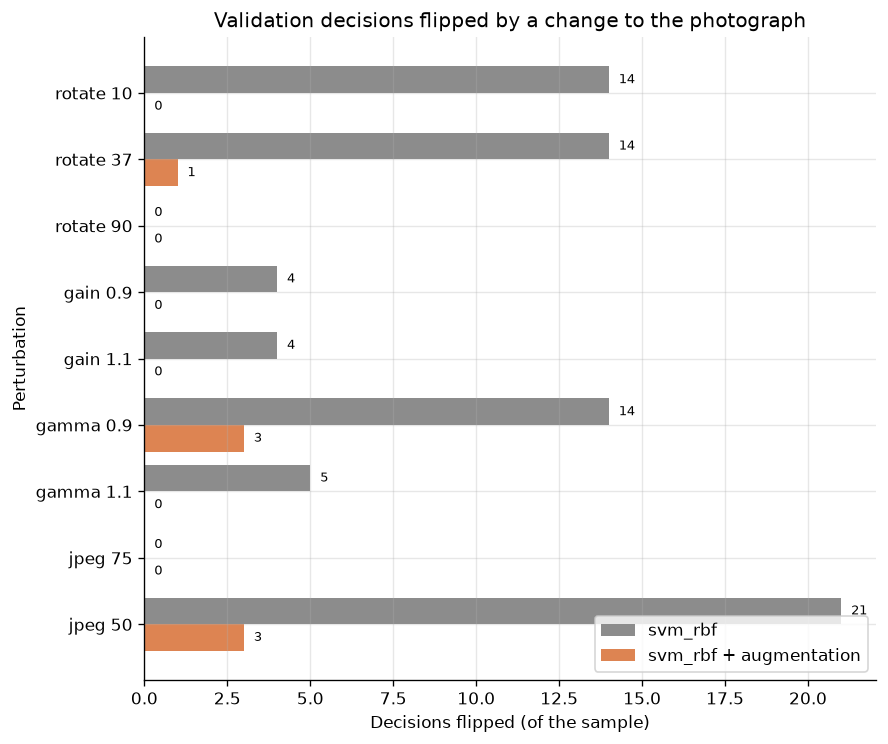

In [22]:
sample = stratified_sample(validation, config.ROBUSTNESS_SAMPLE)
clean_sample = validation_features.set_index("filename").loc[sample["filename"]].reset_index()
family = winner.removesuffix(" + augmentation")
versions = {family: fitted[family], family + " + augmentation": fitted[family + " + augmentation"]}
robustness = robustness_table(clean_sample, perturbed_features(sample, load_grayscale), versions, columns)
display(robustness.pivot(index="perturbation", columns="model", values=["flipped", "false_alarms", "missed_defects"]))
fig = plot_robustness(robustness)
plt.show()
save_figure(fig, "robustness", "modeling")

**Augmentation turns a fragile model into a stable one:** on the same 120 validation images, the model trained without augmentation flips 76 decisions across the nine perturbations; the augmented one flips 7.

- **Rotation:** without augmentation, turning the photograph by 10 or 37 degrees flips 14 decisions, almost all toward false alarms, while a 90-degree turn flips none. Orientation itself is harmless; the damage comes from interpolation, which resamples every pixel and smooths the texture LBP and the top-hat measure. With augmentation, 10 degrees flips nothing and 37 degrees flips one.
- **Tone and exposure:** gain of +/-10% goes from 4 flips to 0, gamma 1.1 from 5 to 0, and gamma 0.9 from 14 to 3.
- **Compression:** JPEG quality 50 goes from 21 flips to 3, and quality 75 flips nothing either way.

The perturbation values were fixed before any model was trained, and the augmentation ranges cover them, so this shows the model learned to ignore these changes within the range a real rig could produce. It does not show robustness to changes outside that range. Photographs should still reach the classifier at the rig's native resolution.

## 13. Final evaluation on the sealed test split

The test partition is read here for the first time: featurized, predicted once with the configuration validation chose, and reported. The shipped model is the one fitted on the exploration split (with its augmented copies); it is not refit on validation, so validation stayed a fair judge of every choice made above.

              precision    recall  f1-score   support

          ok      0.990     0.995     0.993       207
   defective      0.997     0.994     0.995       313

    accuracy                          0.994       520
   macro avg      0.994     0.994     0.994       520
weighted avg      0.994     0.994     0.994       520

missed defects 2, false alarms 1, ROC AUC 0.9965


,quantity,count,estimate,95%_low,95%_high
0,accuracy,517/520,0.9942,0.9832,0.9980
1,recall (defects caught),311/313,0.9936,0.9770,0.9982
2,precision (flags that were defects),311/312,0.9968,0.9821,0.9994
3,false-alarm rate (sound parts rejected),1/207,0.0048,0.0009,0.0269


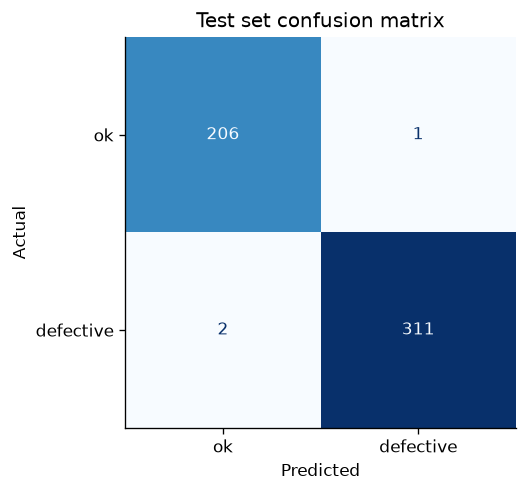

In [23]:
test_features = describe_batch(test, load_grayscale)
y_test = test_features["label"].to_numpy()
predicted = shipped.predict(test_features[columns])
margin = decision_scores(shipped, test_features[columns])
final = evaluate(y_test, predicted, margin)

print(report(y_test, predicted))
print(f"missed defects {final['missed_defects']}, false alarms {final['false_alarms']}, ROC AUC {final['roc_auc']:.4f}")
display(headline_intervals(y_test, predicted))
fig = plot_confusion(y_test, predicted)
plt.show()
save_figure(fig, "confusion_matrix", "evaluation")

**On the sealed test split the shipped model gets 517 of 520 castings right: 99.4% accuracy, F1 0.995 for the defective class, two missed defects out of 313 and one false alarm out of 207:** the confidence intervals are what the headline can support. With 95% confidence, accuracy lies between 98.3% and 99.8%, recall between 97.7% and 99.8%, and the false-alarm rate between 0.1% and 2.7%.

**Test and validation agree once the variability of one split is accounted for:** validation had 6 false alarms in 156 sound castings (3.8%), test has 1 in 207 (0.5%), and the group-aware cross-validation above showed single folds ranging from 0% to 9.7%. Both numbers sit inside that range, and the development mean of 1.3% is the best single estimate of what new castings from this rig would see.

,filename,label,margin,axis_ratio
7,cast_def_0_1192.jpeg,1,-0.036,0.868
165,cast_def_0_5933.jpeg,1,-0.040,0.891
387,cast_ok_0_477.jpeg,0,1.564,0.871


explore cavity axis ratio, percentiles 1/5/50: [0.792 0.834 0.936]


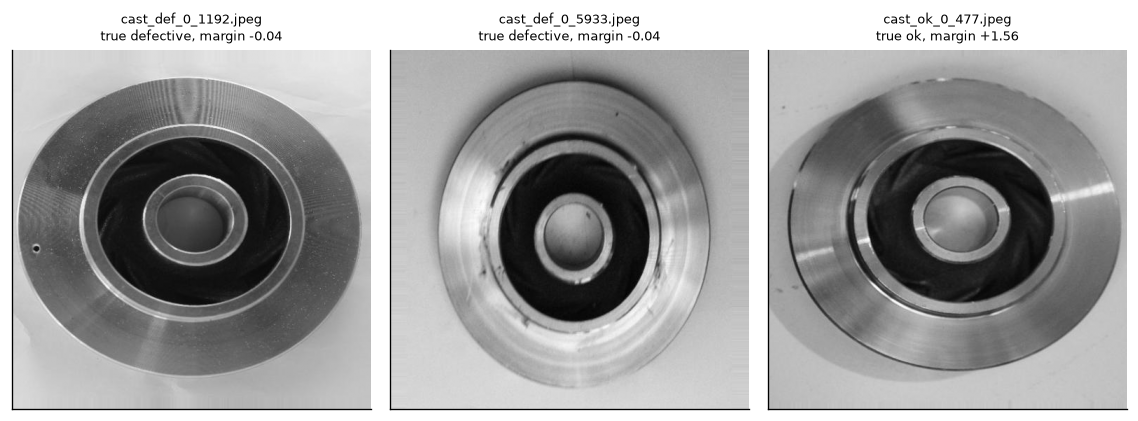

In [24]:
test_path = test.set_index("filename")["path"]
errors = test_features.loc[predicted != y_test, ["filename", "label"]].assign(margin=margin[predicted != y_test])
errors["axis_ratio"] = [quality_metrics(load_grayscale(test_path[name]))["anchor_axis_ratio"] for name in errors["filename"]]
display(errors.round(3))
print("explore cavity axis ratio, percentiles 1/5/50:", np.round(np.percentile(quality["anchor_axis_ratio"], [1, 5, 50]), 3))
if len(errors):
    fig = plot_errors(errors, test_path, load_grayscale, columns=5)
    plt.show()
    save_figure(fig, "test_errors", "evaluation")

**All three errors are informative, and none comes from lighting:**

- **`cast_def_0_1192`** has one small hole at the very edge of the part. It sits at the outer boundary of the inspected band, where the band stops to stay clear of the confounded background, so the features barely see it. The margin of -0.04 is a hair on the wrong side.
- **`cast_def_0_5933`** has dents along the inner edge of the rim and a margin of -0.04, another borderline miss.
- **`cast_ok_0_477`** is a sound casting photographed at a tilt: the part appears as an ellipse with a heavy shadow along one side. The pipeline assumes a round part seen from above, so the band no longer follows the rim, and the shadow reads as damage with high confidence (margin +1.56).

**A tilt gate on the cavity would not have caught it:** the natural check is the cavity's axis ratio, but this photograph's is 0.871, above the 5th percentile of ordinary exploration photographs (0.834). A gate strict enough to catch it would also reject more than 5% of ordinary photographs. Tilt shows in the part's outer silhouette rather than in the cavity, so the fix belongs on the rig: a fixed camera mount, or a silhouette check, which needs the part's outer edge and runs into the bright background again.

## 14. Finding the defect, not just naming it

The top-hat response is bright wherever the surface is locally darker than its surroundings, and on this part that includes structure every casting has: the groove beside the cavity and the chamfer at the outer edge both read as "darker than the metal beside it" at some radius. The first version of this feature thresholded the raw response and boxed those rings on every casting, sound or defective.

The localizer now compares the response, ring by ring, with what **sound** castings from the exploration split produce at the same radius. The reference is a high quantile of sound metal per ring, and a defect is whatever exceeds it. The quantile and the minimum region area were chosen together on the exploration split: the pair that boxes the most defective castings while boxing at most 10% of sound ones. When the classifier flags a casting and no region clears the reference, the single most anomalous spot is boxed with a dashed line, as weaker evidence.

chosen on explore: 99.99th percentile reference, minimum region 10 px


sound_boxed               defective_boxed              
quantile      0.9990 0.9995 0.9999          0.9990 0.9995 0.9999
min_area                                                        
10             0.288  0.199  0.083           0.684  0.607  0.530
20             0.237  0.154  0.051           0.637  0.581  0.483
40             0.179  0.103  0.026           0.603  0.526  0.406
80             0.115  0.077  0.019           0.526  0.436  0.350
160            0.090  0.064  0.013           0.427  0.342  0.265

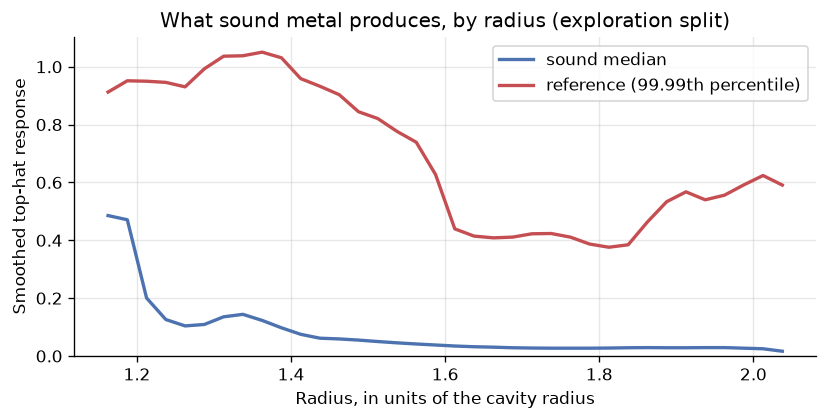

In [25]:
localizer = fit_localizer(explore, load_grayscale)
print(f"chosen on explore: {100 * localizer.quantile:g}th percentile reference, minimum region {localizer.min_area} px")
display(localizer.selection.pivot(index="min_area", columns="quantile", values=["sound_boxed", "defective_boxed"]))
sound_histograms = sum(ring_histograms(load_grayscale(p), localizer.edges)
                       for p in explore.loc[explore["label"] == config.OK, "path"])
fig = plot_localizer_reference(localizer.edges, localizer.curve, localizer.quantile,
                               quantile_curve(sound_histograms, 0.5))
plt.show()
save_figure(fig, "localizer_reference", "evaluation")

**The reference is the curve a defect has to clear:** on sound castings the median response is near zero beyond 1.4 cavity radii and high only at the band's inner edge, where the cavity steps down. The 99.99th percentile is highest from 1.15 to 1.45 radii, where the groove beside the cavity runs, and rises again toward the outer chamfer. Those are the structural rings the first version boxed on every casting. They are now part of "what sound metal looks like" at those radii, so they no longer produce boxes, and a pit on the flat middle of the rim, where the reference is lowest, needs the least response to be found.

The selection table shows the trade the rule made. Every looser setting boxes more defective castings and more sound ones, and the pair chosen (99.99th percentile, 10 px) boxes 53% of defective exploration castings while boxing 8.3% of sound ones, under the 10% target.

In [26]:
print("validation (development check):")
display(box_rates(validation, load_grayscale, localizer))
print("test (final, once):")
display(box_rates(test, load_grayscale, localizer))

validation (development check):


,class,images,boxed_%,boxes_per_boxed_image,median_largest_side_px
0,ok,156,7.7,2.50,74.0
1,defective,234,64.1,2.28,26.5


test (final, once):


,class,images,boxed_%,boxes_per_boxed_image,median_largest_side_px
0,ok,207,9.2,2.05,49.0
1,defective,313,47.3,2.10,20.5


**The boxes are local, and they generalize:** on validation, 7.7% of sound castings get a box, close to the 8.3% fitted on explore, and 64.1% of defective castings do. On test the rates are 9.2% and 47.3%. The median box on a defective casting is 20 to 27 px across, a spot on the rim, where the earlier raw-threshold version drew boxes around the whole cavity.

The defective-with-a-box rate is the honest weak point, and the figure below shows why. Some defects sit outside the inspected band (burrs and flash past the part's edge, holes at the outer rim), because the band stops at 2.05 cavity radii to stay clear of the confounded background. Others are shallow enough to stay under a reference strict enough to leave sound castings alone. When the classifier flags a casting and nothing clears the reference, the most anomalous spot is boxed with a dashed line, so every flagged part still points the operator somewhere, labeled as weaker evidence.

The dataset marks no defect locations, so no localization accuracy can be computed. These rates are the measurable part.

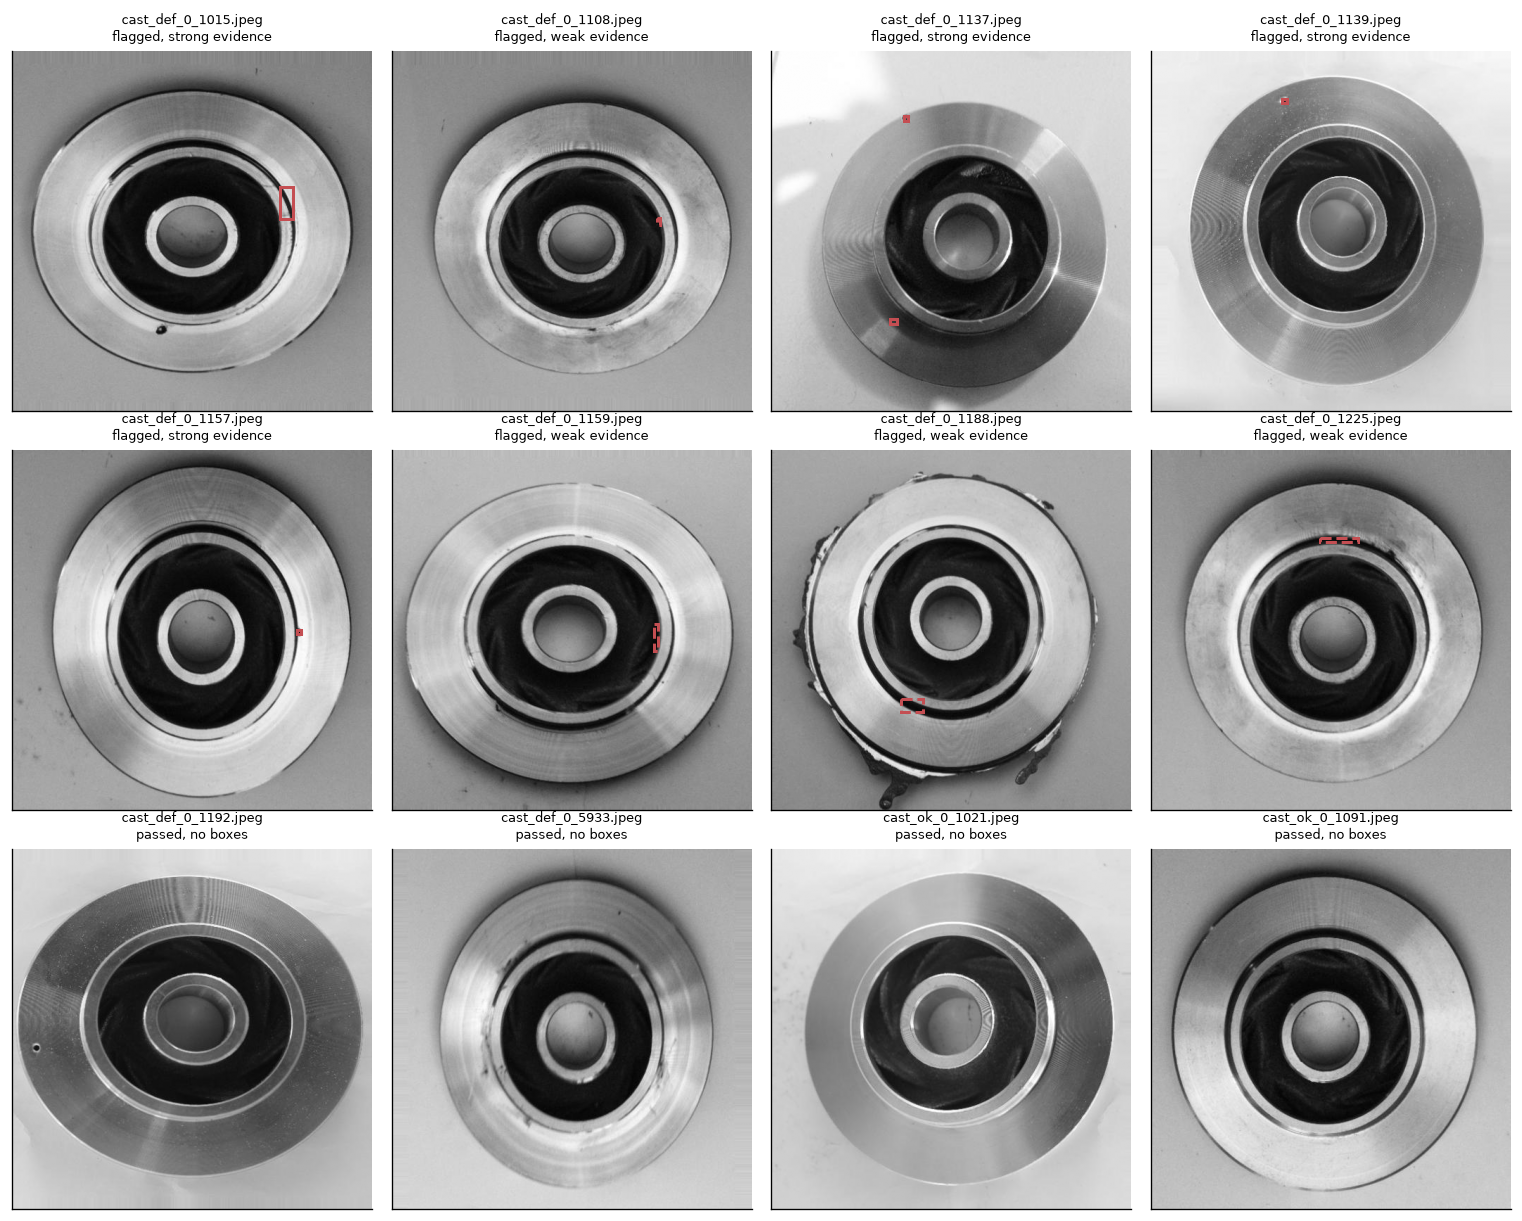

In [27]:
decision = pd.Series(predicted, index=test_features["filename"])
names = (list(decision[decision == config.DEFECT].index[:config.DETECTION_GRID_FLAGGED])
         + list(decision[decision == config.OK].index[:config.DETECTION_GRID_PASSED]))
fig = plot_detection_grid(inspection_gallery(names, test_path, load_grayscale, shipped, columns, localizer), columns=4)
plt.show()
save_figure(fig, "detections", "evaluation")

**The first two rows are the first eight castings the classifier flagged, and the last row four it passed:** the strong boxes are small and sit on marks on the machined rim, such as the chip at the cavity edge of `cast_def_0_1015` and the spots on the rims of `1137`, `1139` and `1157`. The dashed weak boxes of `1108`, `1159`, `1188` and `1225` mark the inner rim edge where each casting's response peaks without clearing the reference. The misses are the ones the section above predicts: the dark hole near the outer edge of `1015` and the flash around `1188` sit outside the band. The passed row includes `cast_def_0_1192` and `cast_def_0_5933`, the two defects the classifier missed, so they have no boxes; the brief asks for boxes only when a defect is detected.

## 15. Processing time

Timed as the product runs: file on disk to decision and boxes, one image at a time on one core, repeated three times over validation images. That includes loading, the full feature pipeline, the SVM's prediction and, for castings it flags, localization. The median and the 95th percentile are reported because on a production line the slow image sets the pace.

In [28]:
timing = time_inspection(validation["path"].head(config.TIMING_SAMPLE), load_grayscale,
                         lambda image: inspect_casting(image, shipped, columns, localizer),
                         repeats=config.TIMING_REPEATS)
display(pd.Series(timing))

images_timed         300.0
median_ms            148.9
p95_ms               159.5
mean_ms              150.1
images_per_second      6.7
dtype: float64

**The whole product runs at a median of 149 ms per image, 160 ms at the 95th percentile, or about 7 castings per second on one core, with no GPU and no neural network:** that is from JPEG on disk to a decision and, for flagged parts, the boxes. The mean and median agree closely, so there is no long tail of slow images.

Most of that time is the three-radius top-hat, which section 10 cut from 1.4 s to 112 ms. Each image is processed independently, so a line with several cameras scales by running one process per core, which is how `describe_batch` featurizes whole partitions in this notebook.

In [29]:
results = {"winner": winner, "settings": shipped.best_params_, "test": final, "timing": timing,
           "localizer": {"quantile": localizer.quantile, "min_area": localizer.min_area}}
tables = {"features_explore": explore_features, "features_validation": validation_features,
          "features_test": test_features, "validation_results": board,
          "duplicate_groups": cleaned[["filename", "group"]]}
print(write_processed(tables, results))

['duplicate_groups.csv', 'features_explore.csv', 'features_test.csv', 'features_validation.csv', 'test_results.json', 'validation_results.csv']


Every artifact in `data/processed/` is written by the cell above, so nothing there can go stale relative to the notebook.

## 16. Conclusion, limitations, and recommendations

### Conclusion

A classical image-processing pipeline classifies metal castings on a sealed, group-aware test split at **99.4% accuracy (95% CI 98.3 to 99.8%)**, missing 2 of 313 defects and rejecting 1 of 207 sound castings, in a median 149 ms per image on one core. Group-aware cross-validation over the 780 development images puts the expected accuracy at 99.1% and the false-alarm rate at 1.3%, with single folds between 0% and 9.7%.

**Two data problems would have made a number like this meaningless, and both were measured before modeling:**

- **The same castings were photographed repeatedly:** 721 of 1,300 images belong to 249 castings photographed more than once. A plain split would have put a twin of 128 test images into the training data, and ordinary cross-validation folds would have rewarded memorizing them. Every split and every fold here keeps a casting's photographs together.
- **The classes were photographed under different light:** a classifier on workbench pixels alone reaches 0.851 validation accuracy. The exposure-matched control shows the shipped model does not depend on it: with background brightness equalized, the background probes fall from 0.775 to 0.477, chance, while the part features hold at 0.971.

**Every design choice was tested against the alternative it replaced:** the cavity anchor against Otsu (which grabs 74% of the frame), the weighted score against an OR of alarms (52% recall), the median against a Gaussian (1 missed defect against 10), the decomposed top-hat against plain disks (12.8 times faster, 1.3% change), the sound-metal reference against raw-threshold boxes, and augmentation against none (6 false alarms against 12, and 7 flipped decisions against 76 under perturbation).

### Limitations

- **Localization is partial and unlabeled:** boxes are local and sit on the rim, but only 47 to 64% of defective castings clear the strict reference, damage past the part's edge is outside the band, and no location labels exist to compute accuracy against.
- **Geometry is assumed:** the one false alarm is a casting photographed at a tilt, and the cavity's shape cannot flag it: its axis ratio is ordinary.
- **The band's outer bound costs detections:** it stops at 2.05 cavity radii to avoid the confounded background, and one of the two missed defects is a hole right at that edge.
- **Robustness is shown only within the augmented range:** rotations, tone curves of +/-15% and JPEG quality 40 to 90. Changes outside that range are untested.
- **One rig, one product:** every image is the same impeller on the same bench. Nothing here shows the pipeline transfers to another casting, camera or lamp.
- **The model comparison is not decisive:** the augmented SVM and forest are statistically indistinguishable on validation (McNemar p = 0.22), and the forest ranks castings better across thresholds.

### Recommendations

- **Photograph both classes in one session:** this fixes the lighting confound at the source; everything in sections 6 and 11 about it exists because that was not done.
- **Fix the camera mount** so the part is always seen from directly above, which removes the tilt failure at no computational cost.
- **Label defect locations on a few hundred images,** so localization can be scored by intersection-over-union and the band can be widened past the part's edge, where burrs, flash and edge holes occur, once the background no longer carries a confound.
- **Set the operating point from real costs:** the threshold table in section 11 shows the trade; the forest's better ranking (AUC 0.992) makes it the candidate if the factory wants a very different point on that curve.
- **Validate on a new batch** from the production line, photographed the same way, before trusting any of these rates beyond this rig and this dataset.